# Steps of the Data Analysis of Astro

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.fft import fft, fftfreq, ifft
from scipy.signal import decimate

Convert .dat file to csv   

CSV file format :

column 1 : flux

In [2]:
import csv

def dat_to_csv(filename, csv_filename):
    """
    Convert .dat file to csv file.

    Args:
        filename (type): the .dat file to be converted
        csv_filename (type): the name for the csv file
    """
    y_data_list = np.fromfile(filename, dtype=np.float32)
    #x_data_list = np.linspace(1.4205 -0.003840/2, 1.4205000 +0.003840/2, 4096)

    with open(csv_filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)

        writer.writerow(['y_axis'])
        rows = zip(y_data_list)
        writer.writerows(rows)

In [3]:
def get_avg_signal(time_series, fft_size):

    reshaped = time_series.reshape(-1, fft_size)
    return reshaped.mean(axis=0)

Οδηγιές:

Αν εχουμε κανει on/off παρατηρηση τοτε θετουμε την μεταβλητη calibration=True

Με το fft_size οριζουμε ανα ποσα σημεια θα γινεται το averaging στην χρονοσειρα

Στα αρχεια on_filename,off_filename βαζουμε τα αρχεια της παρατηρησεις

Δεν χρειαζεται να ασχοληθειτε με το ειδος τον αρχειων γινεται ο καταλληλος ελεγχος και μεατροπη σε csv αν χρειαστει

Αν δεν εχουμε κανει on\off παρατηρηση και απλα εχουμε παρατηρησει την πηγη τοτε βαζουμε την μεταβλητη calibration=False και βαζουμε το αρχειο της παρατηρησης στο on_observation_filename

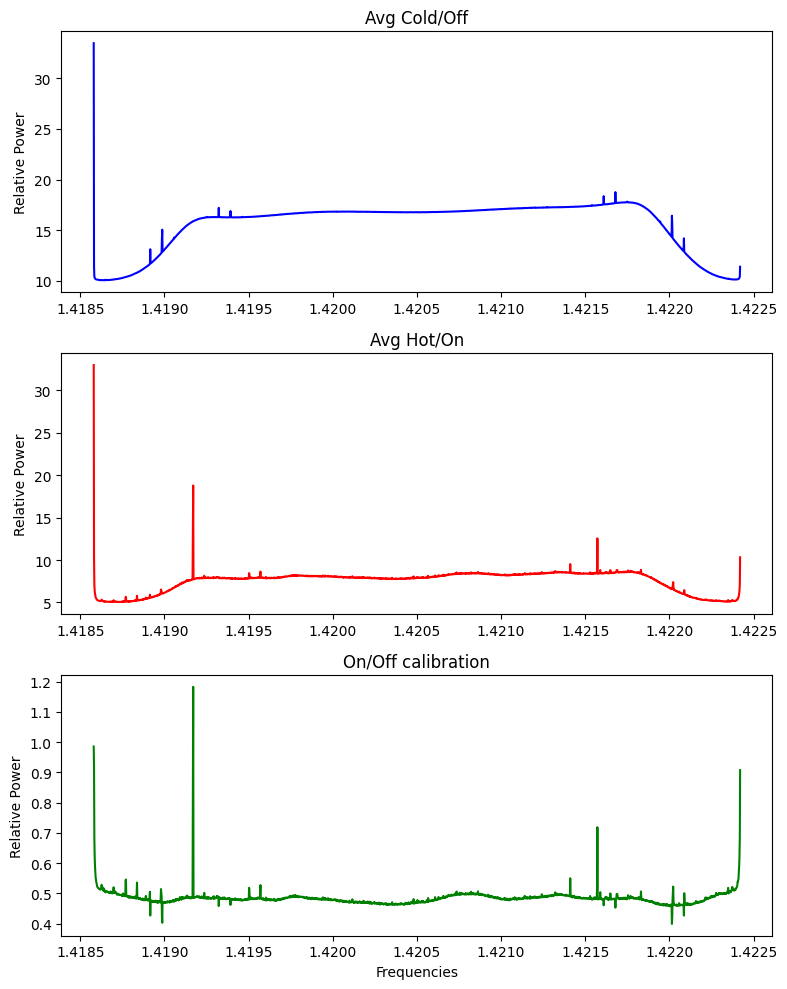

In [32]:
calibration = True
fft_size = 2048
frequencies = np.linspace(1.4205 -0.003840/2, 1.4205000 +0.003840/2, fft_size)

on_observation_filename = "2502202_Hot202020.csv"
off_observation_filename = "2502202_Cold202020.csv"

if on_observation_filename.endswith(".dat"):
    on_observation_filename = f"{on_observation_filename.split('.')[0]}.csv"
    dat_to_csv(on_observation_filename.split('.')[0] + ".dat",on_observation_filename)
if off_observation_filename.endswith(".dat"):
     off_observation_filename = f"{off_observation_filename.split('.')[0]}.csv"
     dat_to_csv(off_observation_filename.split('.')[0] + ".dat",off_observation_filename)

# If we dont wnat to calibrate then we use the on signal
on_series_df = pd.read_csv(on_observation_filename)
on_series_df = on_series_df.filter(regex='power_au|y_axis')
on_series_np = on_series_df.to_numpy()
avg_on = on_series_np
if len(on_series_np) > fft_size:
    avg_on = get_avg_signal(on_series_np, fft_size)

if calibration == True :
    off_series_df = pd.read_csv(off_observation_filename)
    on_series_df = on_series_df.filter(regex='power_au|y_axis')
    off_series_np = off_series_df.to_numpy()
    avg_off = off_series_np
    if len(off_series_np) > fft_size:
        avg_off = get_avg_signal(off_series_np, fft_size)
    calibrated_signal = avg_on/avg_off

    fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(8, 10))

    ax1.plot(frequencies, avg_off, color='blue')
    ax1.set_title('Avg Cold/Off')
    ax1.set_ylabel('Relative Power')

    ax2.plot(frequencies, avg_on , color='red')
    ax2.set_title('Avg Hot/On')
    ax2.set_ylabel('Relative Power')

    ax3.plot(frequencies, calibrated_signal, color='green')
    ax3.set_title('On/Off calibration')
    ax3.set_ylabel('Relative Power')
    ax3.set_xlabel('Frequencies')
    plt.tight_layout()
    plt.show()
else:
    plt.plot(frequencies, avg_on, color='blue')
    plt.title('Target signal')
    plt.ylabel('Relative Power')
    plt.xlabel('Frequencies')
    plt.show()